# Method Analysis

* VNeo method parsing adapted from from https://github.com/nickdelgrosso/XCaliburMethodReader/tree/master

## Imports

In [1]:
# import olefile
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import seaborn as sns
import os
import sys
import anndata as ad
import zipfile
from pathlib import Path
import tempfile

# %matplotlib inline

In [2]:
%load_ext autoreload
%autoreload 2

project_root = os.path.abspath(os.path.join(os.getcwd(), '../..'))
src_path = os.path.join(project_root, 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

# Now import from the modules
from parsers.vneometh.vneo_method import VNeoMethod
from parsers.vneometh.lc_method_collection import VNeoMethodCollection
from parsers.timsmeth.ms_method_collection import MSMethodCollection
from parsers.search.search_loader import SearchLoader
from parsers.search.search_collection import SearchCollection

# Integrator tools
from integrator.filters import filter_mask
from integrator.method_mapper import map_lcms_methods

from plotting.dash import DashPlots

In [3]:
import ipywidgets as widgets
from IPython.display import display, clear_output

In [4]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

### BPS

In [43]:
bpscollection = SearchCollection(log_file = '/hpc/projects/mass_spec/eileenwang/TTQC/log/collection.log', 
                                 search_type='bps_diann',
                                 config_path='/hpc/projects/mass_spec/eileenwang/MethodOpt/LCMSmethodAnalysis/src/parsers/search/diann_columns.yaml')

In [42]:
# bpscollection.add_searches('/hpc/projects/mass_spec/eileenwang/TTQC/artifact-export(2).zip',
#                             levels=['precursor'])

In [44]:
bpscollection.add_searches('/hpc/projects/mass_spec/eileenwang/TTQC/artifact-export(3).zip',
                            levels=['precursor'])

Loading BPS DIA-NN export from: /hpc/projects/mass_spec/eileenwang/TTQC/artifact-export(3).zip
Opening export zip: /hpc/projects/mass_spec/eileenwang/TTQC/artifact-export(3).zip
Found 20 tims-diann.result.zip files
  - processing-runs/12d79f57-32c7-4b34-8c41-1a75ef358ac6/p8s/tims-diann.result.zip
  - processing-runs/6093800e-bb4c-42dd-8209-9e441f10501e/p8s/tims-diann.result.zip
  - processing-runs/b48dbed2-d0da-4dad-8cfb-d7fd410904e6/p8s/tims-diann.result.zip
  - processing-runs/b9bcc7fb-9d63-413f-ab08-5b5567f54986/p8s/tims-diann.result.zip
  - processing-runs/99775a2e-2f6b-4290-affc-81514ba38fd1/p8s/tims-diann.result.zip
  - processing-runs/f020fe32-36ad-4e7c-8002-cf707b228705/p8s/tims-diann.result.zip
  - processing-runs/7767283e-2e0f-4ff6-b746-87bf88288021/p8s/tims-diann.result.zip
  - processing-runs/42decf5e-57c1-4ebb-ba5d-34a3fc0f5852/p8s/tims-diann.result.zip
  - processing-runs/254defd6-8f19-49b0-89df-8f4794972c68/p8s/tims-diann.result.zip
  - processing-runs/1729bf3a-7598-44ef

In [56]:
bpscollection['precursor']

AnnData object with n_obs × n_vars = 88381 × 20
    obs: 'Modified.Sequence', 'Stripped.Sequence', 'Precursor.Charge', 'Precursor.Id'
    var: 'File.Name', 'Run', 'search_path', 'search_type', 'hystar_index'
    layers: 'Precursor.Normalised', 'Precursor.Quantity', 'Proteotypic', 'iRT', 'Predicted.RT', 'Predicted.iRT', 'Q.Value', 'Quantity.Quality', 'RT', 'RT.Start', 'RT.Stop', 'Lib.Q.Value', 'Ms1.Profile.Corr', 'Ms1.Area', 'Evidence', 'CScore', 'Decoy.Evidence', 'Decoy.CScore', 'Fragment.Quant.Raw', 'Fragment.Quant.Corrected', 'Fragment.Correlations', 'MS2.Scan', 'Fragment.Info', 'Precursor.FWHM', 'Precursor.Error.Ppm', 'Corr.Precursor.Error.Ppm', 'Data.Points', 'Ms1.Iso.Corr.Sum', 'Library.Precursor.Mz', 'Corrected.Precursor.Mz', 'Precursor.Calibrated.Mz', 'Fragment.Calibrated.Mz', 'Exp.1/K0', 'Lib.1/K0', 'Protein.Group', 'Protein.Ids'

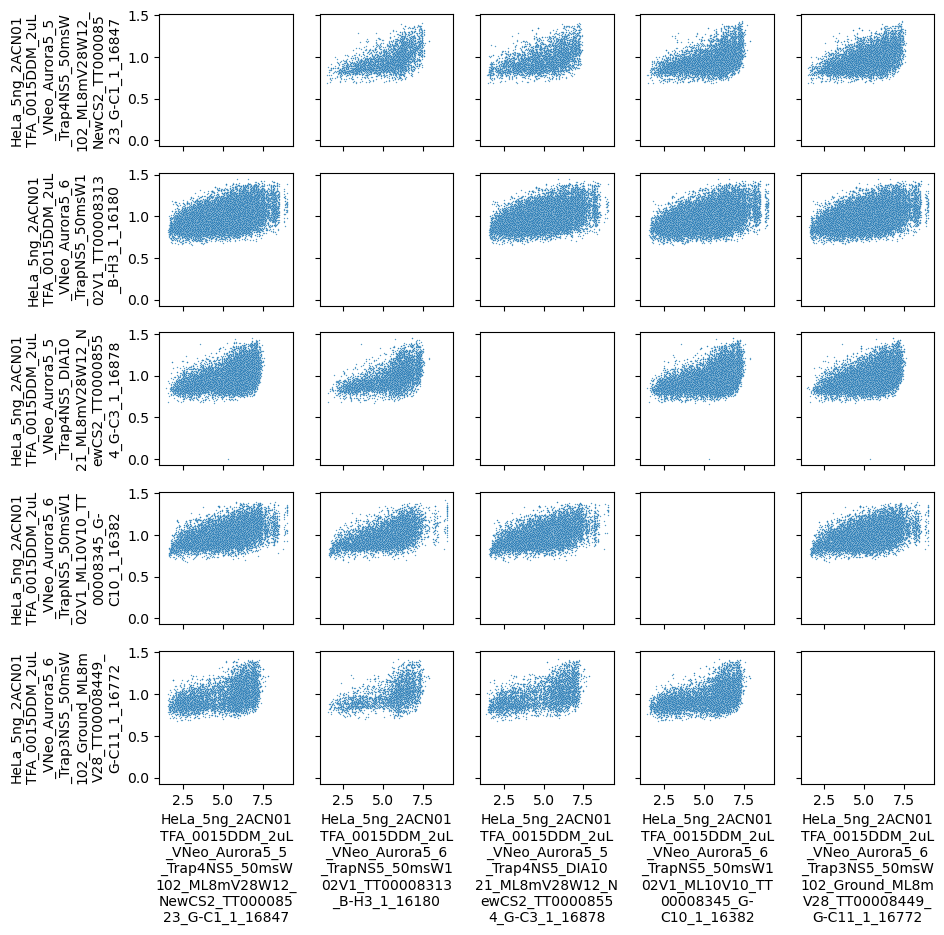

In [97]:
fig, ax = plt.subplots(nrows=5, ncols=5, figsize=(10, 10), sharex=True, sharey=True)

for i, x in enumerate(bpscollection['precursor'].var_names[:5]):
    for j, y in enumerate(bpscollection['precursor'].var_names[:5]):
        # Extract RT values and flatten to 1D arrays
        mask = bpscollection['precursor'][:, y].layers['Precursor.Quantity'] > 0

        vals = bpscollection['precursor'][:, x][~mask, :].layers['RT'].flatten()
        
        sns.scatterplot(x = vals,
                        y = bpscollection['precursor'][:, x][~mask, :].layers['Exp.1/K0'].flatten(),
                        ax=ax[i, j],
                        s=1,
                        alpha=0.75)
        if j == 0:
            ax[i, j].set_ylabel(textwrap.fill(x, width=15))
        if i == 4:
            ax[i, j].set_xlabel(textwrap.fill(y, width=15))

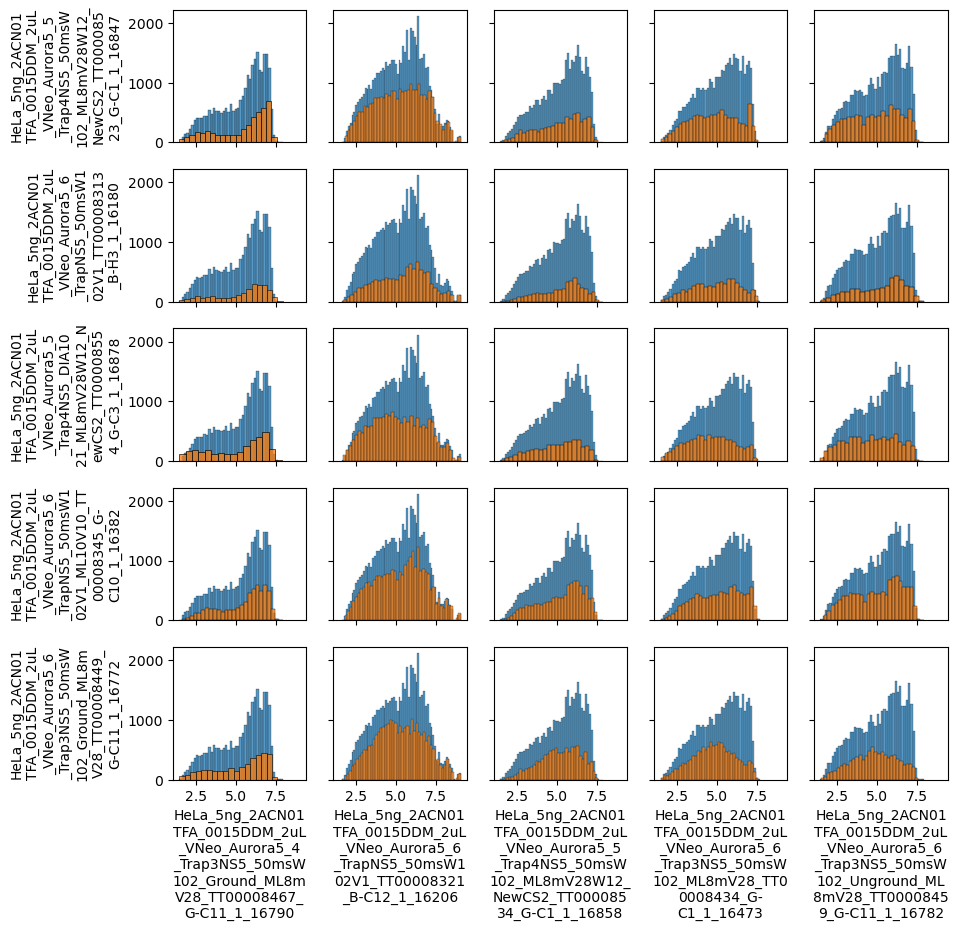

In [105]:
fig, ax = plt.subplots(nrows=5, ncols=5, figsize=(10, 10), sharex=True, sharey=True)

for i, x in enumerate(bpscollection['precursor'].var_names[:5]):
    for j, y in enumerate(bpscollection['precursor'].var_names[5:10]):
        # Extract RT values and flatten to 1D arrays
        # Mask based on whether x (row) has quantity
        mask = bpscollection['precursor'][:, x].layers['Precursor.Quantity'] > 0

        # Get RT values for y (column) where x doesn't have quantity
        vals = bpscollection['precursor'][:, y][~mask, :].layers['RT'].flatten()

        # Plot histogram for y (corresponds to xlabel)
        sns.histplot(bpscollection['precursor'][:, y].layers['RT'].flatten(),
                     ax=ax[i, j])
        
        sns.histplot(vals,
                     ax=ax[i, j])
        if j == 0:
            ax[i, j].set_ylabel(textwrap.fill(x, width=15))
        if i == 4:
            ax[i, j].set_xlabel(textwrap.fill(y, width=15))

In [64]:
import textwrap


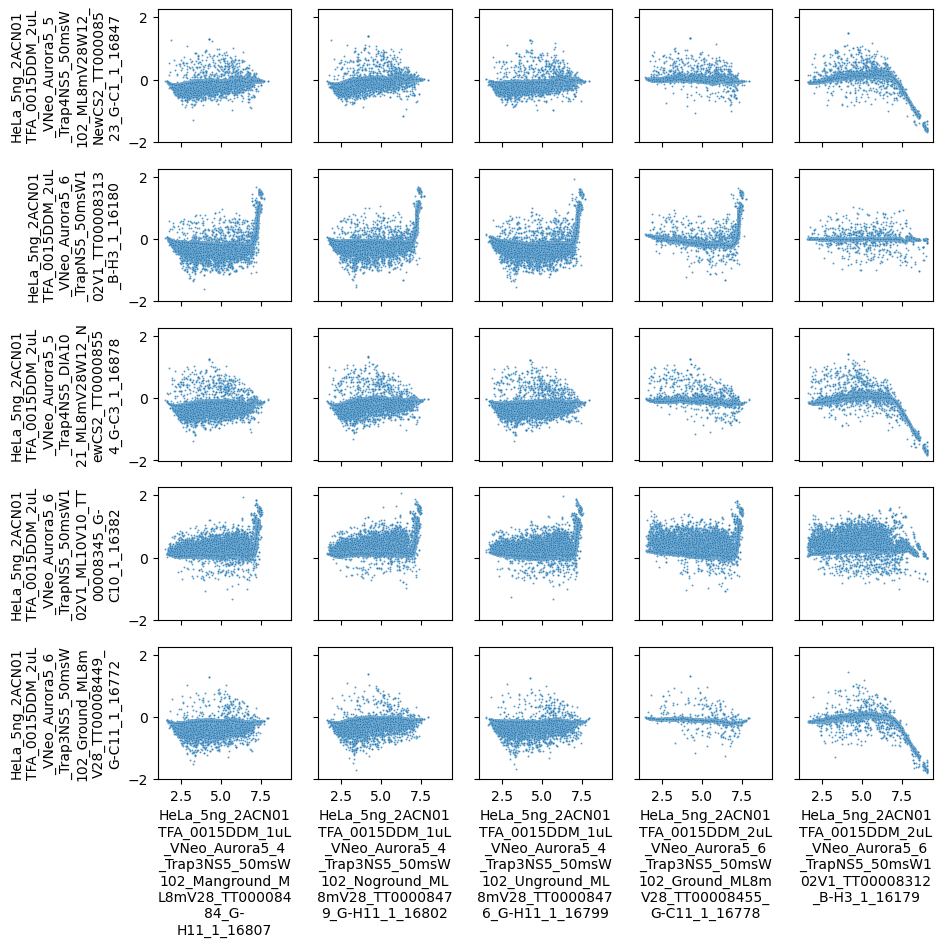

In [106]:
fig, ax = plt.subplots(nrows=5, ncols=5, figsize=(10, 10), sharex=True, sharey=True)

for i, x in enumerate(bpscollection['precursor'].var_names[:5]):
    for j, y in enumerate(bpscollection['precursor'].var_names[15:20]):
        # Extract RT values and flatten to 1D arrays
        rt_x = bpscollection['precursor'][:, x].layers['RT'].flatten()
        rt_y = bpscollection['precursor'][:, y].layers['RT'].flatten()
        
        sns.scatterplot(y=rt_x - rt_y, 
                        x=rt_y,
                        s=2,
                        alpha=0.75, 
                        ax=ax[i, j])
        # Set ylabel for leftmost column - shows which row (x variable)
        if j == 0:
            ax[i, j].set_ylabel(textwrap.fill(x, width=15))
        # Set xlabel for bottom row - shows which column (y variable)
        if i == 4:
            ax[i, j].set_xlabel(textwrap.fill(y, width=15))

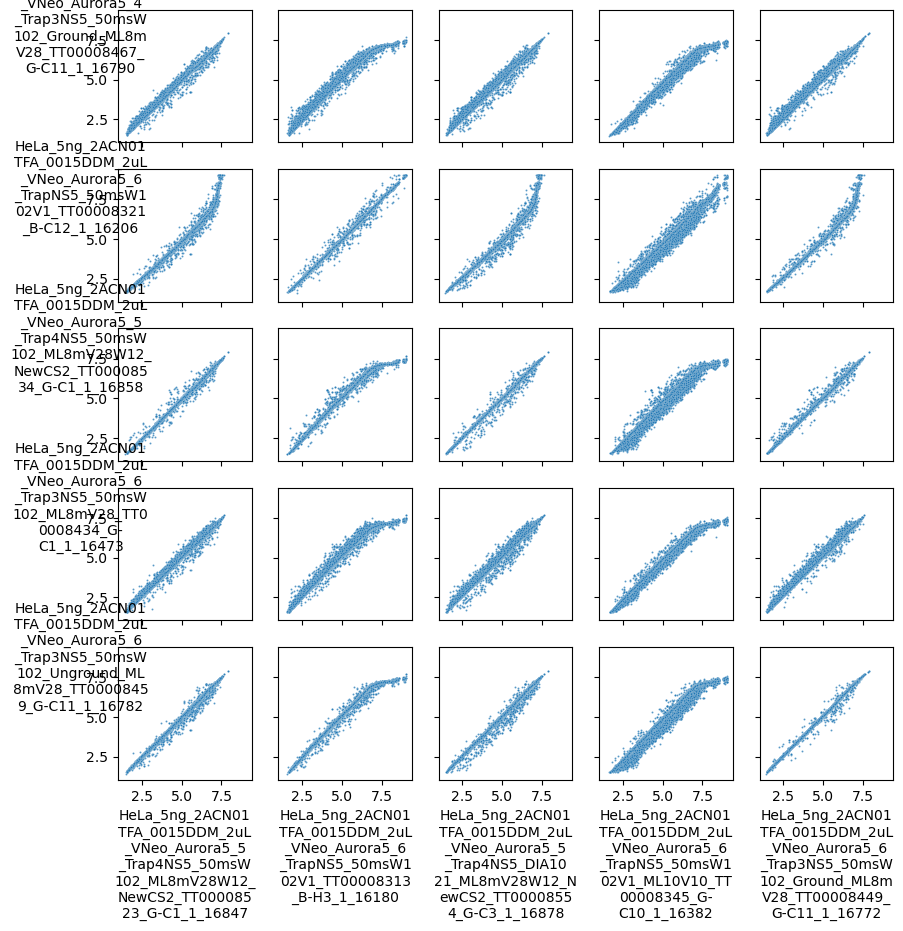

In [90]:
fig, ax = plt.subplots(nrows=5, ncols=5, figsize=(10, 10), sharex=True, sharey=True)

for i, x in enumerate(bpscollection['precursor'].var_names[5:10]):
    for j, y in enumerate(bpscollection['precursor'].var_names[:5]):
        # Extract RT values and flatten to 1D arrays
        rt_x = bpscollection['precursor'][:, x].layers['RT'].flatten()
        rt_y = bpscollection['precursor'][:, y].layers['RT'].flatten()
        
        sns.scatterplot(y=rt_x, 
                        x=rt_y,
                        s=2,
                        alpha=0.75, 
                        ax=ax[i, j])
        if j == 0:
            ax[i, j].set_ylabel(textwrap.fill(x, width=15), rotation=0)
        if i == 4:
            ax[i, j].set_xlabel(textwrap.fill(y, width=15))

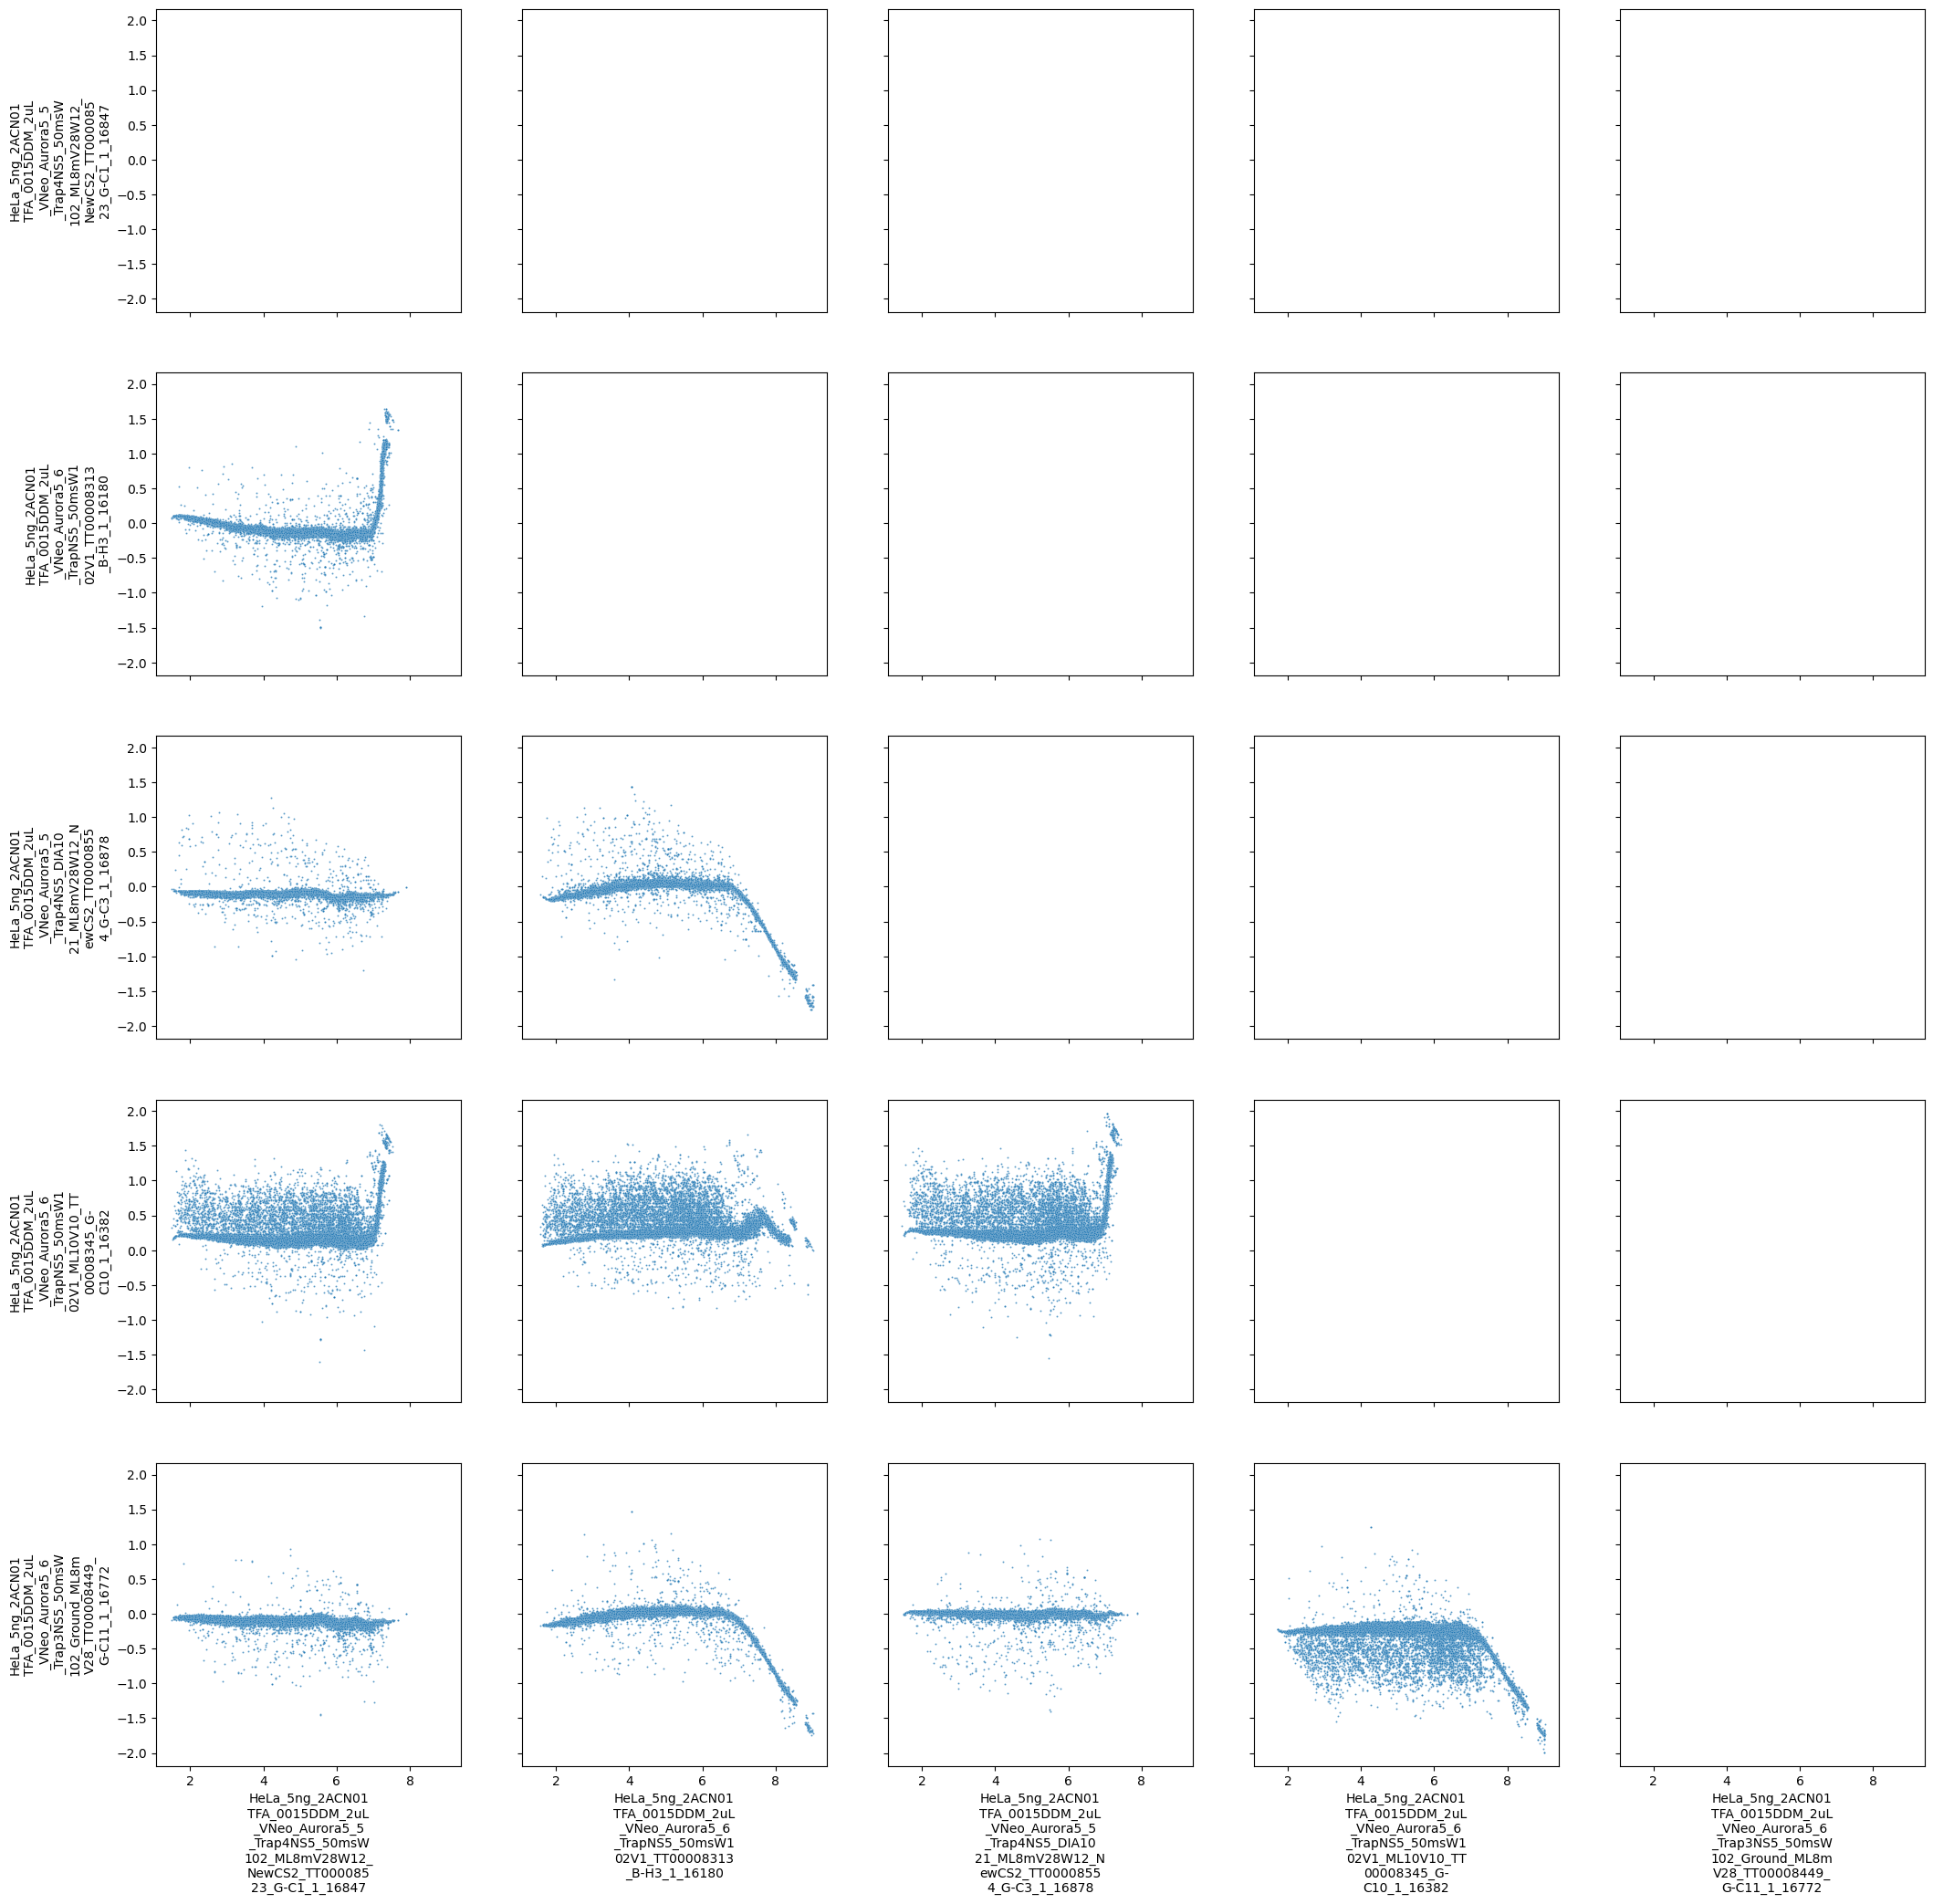

In [71]:
fig, ax = plt.subplots(nrows=5, ncols=5, figsize=(25, 25), sharex=True, sharey=True)

for i, x in enumerate(bpscollection['precursor'].var_names[:5]):
    for j, y in enumerate(bpscollection['precursor'].var_names[:5]):
        if i > j:
            sns.scatterplot(y = bpscollection['precursor'].layers['RT'][:, i] -  bpscollection['precursor'].layers['RT'][:, j], 
                            x = bpscollection['precursor'].layers['RT'][:, j],
                            s=2,
                            alpha=0.75, 
                            ax=ax[i, j])
        if j == 0:
            ax[i, j].set_ylabel(textwrap.fill(x, width=15))
        if i == 4:
            ax[i, j].set_xlabel(textwrap.fill(y, width=15))
                

<Axes: ylabel='Count'>

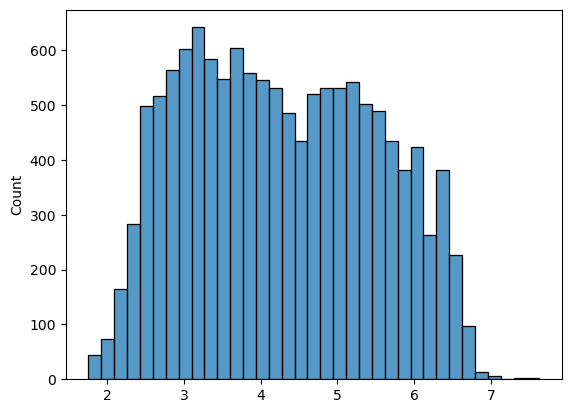

In [19]:
sns.histplot(bpscollection['precursor'].layers['RT'][:, 0])

<Axes: ylabel='Count'>

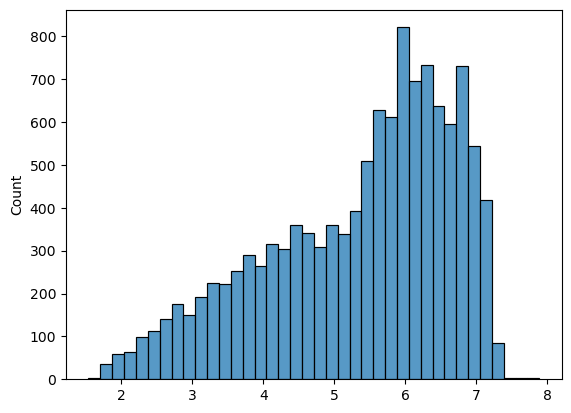

In [20]:
sns.histplot(bpscollection['precursor'].layers['RT'][:, 1])

(8.0, 20.0)

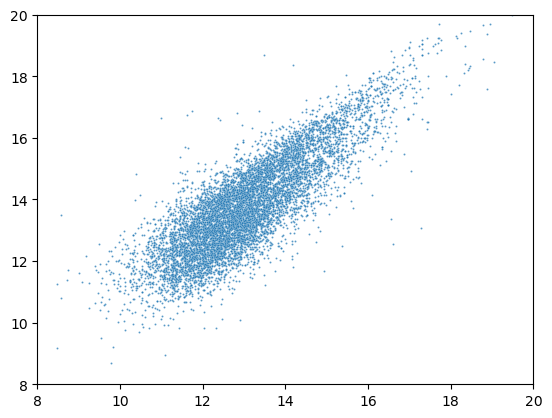

In [39]:
sns.scatterplot(y = np.log2(bpscollection['precursor'].layers['Precursor.Quantity'][:, 0].astype(float)), 
                x = np.log2(bpscollection['precursor'].layers['Precursor.Quantity'][:, 1].astype(float)),
                s=2,
                alpha=0.75)
plt.xlim(8, 20)
plt.ylim(8, 20)

<Axes: >

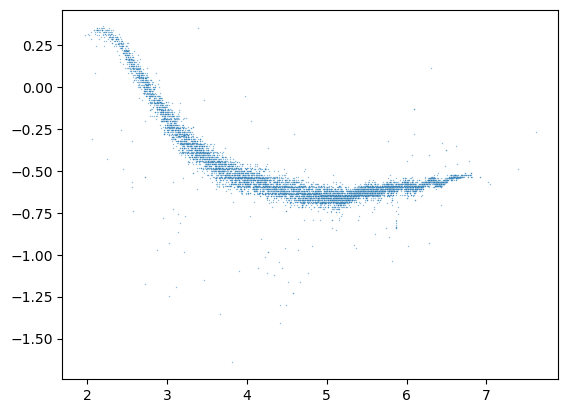

In [40]:
sns.scatterplot(y = bpscollection['precursor'].layers['RT'][:, 0] - bpscollection['precursor'].layers['RT'][:, 1], 
                x = bpscollection['precursor'].layers['RT'][:, 0],
                s=1,
                alpha=0.5)

In [30]:
# bpscollection.save(f'{base}MethodOpt/LCMSmethodAnalysis/notebooks/dev/outputs/trapbpscollection.pkl')

Saved collection to /hpc/projects/mass_spec/eileenwang/MethodOpt/LCMSmethodAnalysis/notebooks/dev/outputs/trapbpscollection.pkl


In [15]:
bpscollection = DiannCollection.from_file(f'{base}MethodOpt/LCMSmethodAnalysis/notebooks/dev/outputs/trapbpscollection.pkl')

Loaded collection from /hpc/projects/mass_spec/eileenwang/MethodOpt/LCMSmethodAnalysis/notebooks/dev/outputs/trapbpscollection.pkl


In [ ]:
# map_lcms_methods(bpscollection, f'{base}MethodOpt/LCMSmethodAnalysis/data/sequences/2026_03.csv')

In [11]:
# bpscollection.save(f'{base}/MethodOpt/outputs/bpscollection.pkl')

Saved collection to /hpc/projects/mass_spec/eileenwang/MethodOpt/outputs/bpscollection.pkl
